In [2]:
import numpy as np
import xarray as xr
import geopandas as gpd
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_origin

WATERSHED_TIF = r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\Dataset - All\WBT_data\WBT_data\pallas_16\korkeusmalli_16m_culverts_water_no_deps_d8_sl_watershed.tif"
POINTS_SHP    = r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\Dataset - All\WBT_data\WBT_data\DTS Locations\stream_temp_points.shp"
MODEL_OUTPUT  = r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\Input\spafhy_input\pallas\results\pallas_analysis_2_2D_202602181223\202602181222_inflow_to_ditch_pos.nc"

ds = xr.open_dataset(MODEL_OUTPUT)
run_da = ds["bucket_surface_runoff"]  

print(run_da)
print("Coords:", list(run_da.coords))

<xarray.DataArray 'bucket_surface_runoff' (time: 1826, lat: 221, lon: 136)> Size: 220MB
[54882256 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 15kB 2019-01-01 2019-01-02 ... 2023-12-31
  * lat      (lat) float64 2kB 7.546e+06 7.546e+06 ... 7.542e+06 7.542e+06
  * lon      (lon) float64 1kB 3.829e+05 3.829e+05 ... 3.851e+05 3.851e+05
Attributes:
    units:    surface runoff [mm d-1]
Coords: ['time', 'lat', 'lon']


In [3]:
with rasterio.open(WATERSHED_TIF) as zsrc:
    zones = zsrc.read(1).astype("float64")
    z_transform = zsrc.transform
    z_crs = zsrc.crs
    z_nodata = zsrc.nodata
    z_shape = zones.shape
    z_bounds = zsrc.bounds

if z_nodata is not None:
    zones[zones == z_nodata] = np.nan

print("Zone raster CRS:", z_crs)
print("Zone raster shape:", z_shape)
print("Zone raster bounds:", z_bounds)

# Quick check: do we have many IDs?
u = np.unique(zones[~np.isnan(zones)])
print("Number of unique zone IDs:", len(u))
print("First 15 IDs:", u[:15])

Zone raster CRS: EPSG:3067
Zone raster shape: (1250, 1250)
Zone raster bounds: BoundingBox(left=370000.0, bottom=7537500.0, right=390000.0, top=7557500.0)
Number of unique zone IDs: 116
First 15 IDs: [ 2.  3.  5.  6.  7.  9. 11. 13. 14. 15. 17. 18. 20. 22. 24.]


In [4]:
pts = gpd.read_file(POINTS_SHP)
if pts.crs is None:
    raise ValueError("Your points shapefile has no CRS. Set it in GIS and re save.")
pts = pts.to_crs(z_crs)

with rasterio.open(WATERSHED_TIF) as zsrc:
    coords = [(g.x, g.y) for g in pts.geometry]
    basin_id = np.array([v[0] for v in zsrc.sample(coords)], dtype="float64")

if z_nodata is not None:
    basin_id[basin_id == z_nodata] = np.nan

pts["basin_id"] = basin_id

print("Points with NaN basin_id:", np.isnan(pts["basin_id"]).sum(), "out of", len(pts))
print(pts[["basin_id"]].head())

Points with NaN basin_id: 0 out of 189
   basin_id
0       2.0
1       2.0
2       3.0
3       5.0
4       5.0


In [5]:
# coord names in your nc
xname = "lon"
yname = "lat"
x = run_da[xname].values
y = run_da[yname].values

def regrid_runoff_to_zonegrid(run2d, x, y, dst_shape, dst_transform, crs):
    dx = float(np.abs(x[1] - x[0]))
    dy = float(np.abs(y[1] - y[0]))
    src_transform = from_origin(x.min() - dx/2, y.max() + dy/2, dx, dy)

    arr = run2d.astype("float32")
    if y[0] < y[-1]:  # y ascending, flip to match raster row order
        arr = np.flipud(arr)

    dst = np.full(dst_shape, np.nan, dtype="float32")
    reproject(
        source=arr,
        destination=dst,
        src_transform=src_transform,
        src_crs=crs,          
        dst_transform=dst_transform,
        dst_crs=crs,
        resampling=Resampling.bilinear
    )
    return dst
valid_zone_mask = ~np.isnan(zones)
zone_ids_all = zones[valid_zone_mask].astype(np.int64)
max_id = int(zone_ids_all.max())

# Precompute point basin IDs as ints
pt_basin = pts["basin_id"].values

profiles = []

for t in range(run_da.sizes["time"]):
    run2d = run_da.isel(time=t).values
    run_on_zones = regrid_runoff_to_zonegrid(run2d, x, y, z_shape, z_transform, z_crs)

    mask = valid_zone_mask & ~np.isnan(run_on_zones)
    zid = zones[mask].astype(np.int64)
    val = run_on_zones[mask].astype(np.float64)

    sum_by = np.bincount(zid, weights=val, minlength=max_id + 1)
    cnt_by = np.bincount(zid, minlength=max_id + 1)

    mean_by = np.full(max_id + 1, np.nan, dtype=np.float64)
    ok = cnt_by > 0
    mean_by[ok] = sum_by[ok] / cnt_by[ok]

    prof = np.full(len(pt_basin), np.nan, dtype=np.float64)
    for i, bid in enumerate(pt_basin):
        if np.isnan(bid):
            continue
        b = int(bid)
        if 0 <= b <= max_id:
            prof[i] = mean_by[b]

    profiles.append(prof)

profiles = np.vstack(profiles)


stream_length = np.arange(len(pts), dtype=float)

bucket_stream = xr.DataArray(
    profiles,
    coords={"time": run_da["time"].values, "stream_length": stream_length},
    dims=("time", "stream_length"),
    name="bucket_surface_runoff_stream"
)

print(bucket_stream)

<xarray.DataArray 'bucket_surface_runoff_stream' (time: 1826, stream_length: 189)> Size: 3MB
array([[0.        , 0.        , 0.0089534 , ..., 0.        , 0.28033186,
        0.28033186],
       [0.        , 0.        , 0.0069205 , ..., 0.        , 0.27574798,
        0.27574798],
       [0.        , 0.        , 0.00715278, ..., 0.        , 0.27449015,
        0.27449015],
       ...,
       [0.        , 0.        , 0.13079399, ..., 0.        , 0.41159423,
        0.41159423],
       [0.        , 0.        , 0.16581902, ..., 0.        , 0.41299258,
        0.41299258],
       [0.        , 0.        , 0.17112621, ..., 0.        , 0.41110735,
        0.41110735]], shape=(1826, 189))
Coordinates:
  * time           (time) datetime64[ns] 15kB 2019-01-01 ... 2023-12-31
  * stream_length  (stream_length) float64 2kB 0.0 1.0 2.0 ... 186.0 187.0 188.0


<xarray.DataArray 'bucket_surface_runoff' (time: 1826, lat: 221, lon: 136)> Size: 220MB
[54882256 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 15kB 2019-01-01 2019-01-02 ... 2023-12-31
  * lat      (lat) float64 2kB 7.546e+06 7.546e+06 ... 7.542e+06 7.542e+06
  * lon      (lon) float64 1kB 3.829e+05 3.829e+05 ... 3.851e+05 3.851e+05
Attributes:
    units:    surface runoff [mm d-1]
Coords: ['time', 'lat', 'lon']
Zone raster CRS: EPSG:3067
Zone raster shape: (1250, 1250)
Unique zone IDs (count): 116
Valid basin_id: 189 / 189
Valid stream_length_m: 189 / 189
<xarray.DataArray 'bucket_surface_runoff_stream' (time: 1826, stream_length: 189)> Size: 3MB
array([[0.        , 0.        , 0.0089534 , ..., 0.28033186, 0.28033186,
        0.28033186],
       [0.        , 0.        , 0.0069205 , ..., 0.27574798, 0.27574798,
        0.27574798],
       [0.        , 0.        , 0.00715278, ..., 0.27449015, 0.27449015,
        0.27449015],
       ...,
       [0.        , 

C:\Users\pparvizi24\AppData\Local\Temp\ipykernel_35540\1602310469.py:394: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


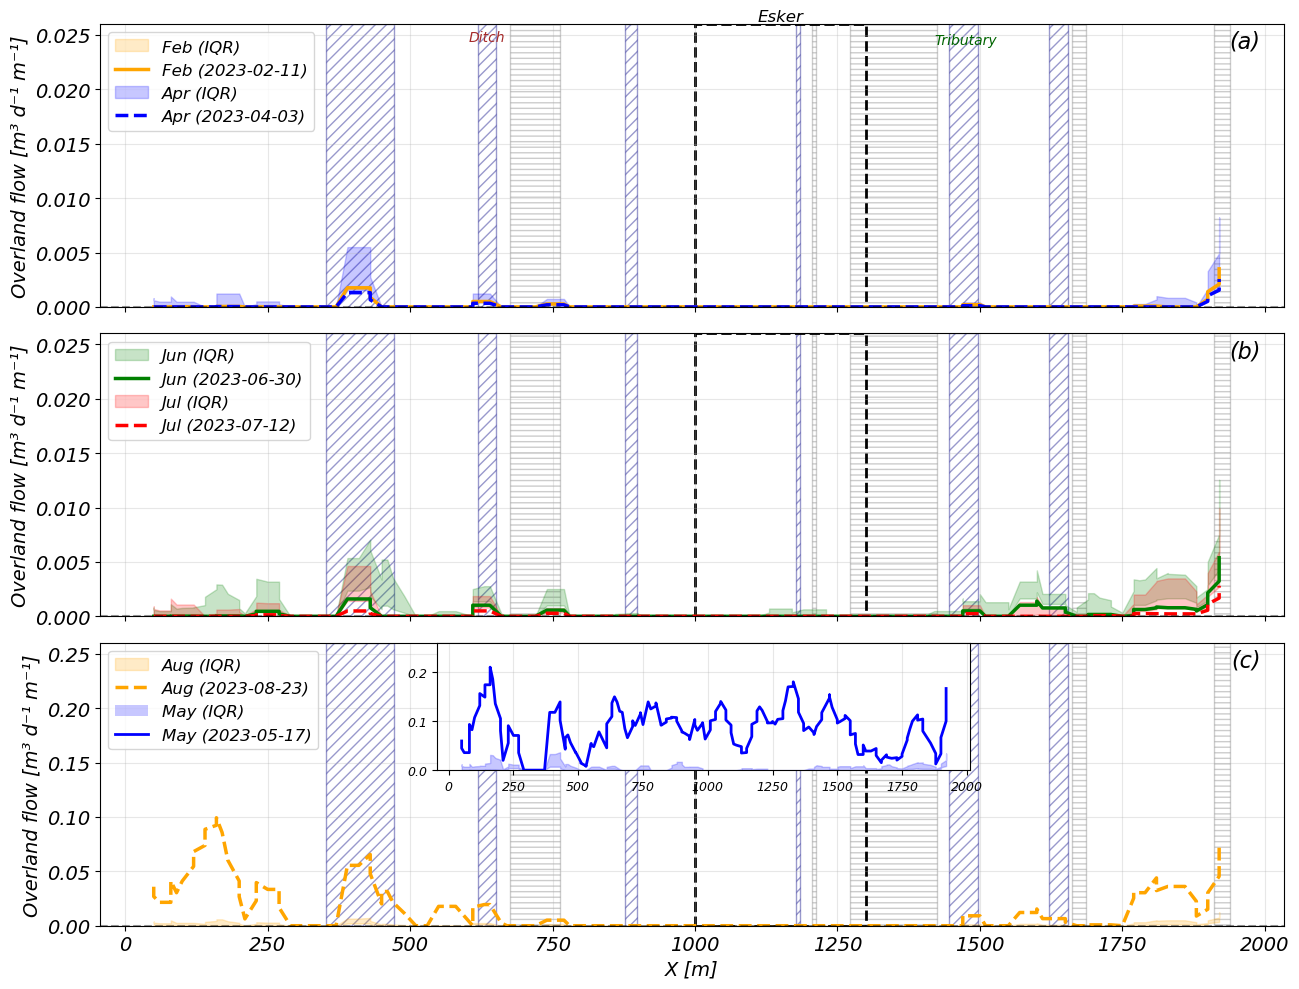

Saved: C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\final plots DTS\Final Final DEC 2025\Final Final Revision plots with SW\bucket_surface_runoff_profile_same_dates_distance.png


In [6]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr
import geopandas as gpd
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_origin
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

MODEL_OUTPUT = r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\Input\spafhy_input\pallas\results\pallas_analysis_2_2D_202602181223\202602181222_inflow_to_ditch_pos.nc"

WATERSHED_TIF = r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\Dataset - All\WBT_data\WBT_data\pallas_16\korkeusmalli_16m_culverts_water_no_deps_d8_sl_watershed.tif"

POINTS_SHP = r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\Dataset - All\WBT_data\WBT_data\DTS Locations\stream_temp_points.shp"

STREAM_LENGTH_TIF = r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\Dataset - All\WBT_data\WBT_data\pallas_16\stream_lengths_burned_clipped.tif"

GW_ZONES_FILE = r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\Clone_DTS\Final-Final-Clone DTS Article\Final Version of DTS Article Codes to Push\FINAL CSV FILES\GW_inflow_locations_slope.csv"

SW_ZONES_FILE = r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\Clone_DTS\Final-Final-Clone DTS Article\Final Version of DTS Article Codes to Push\DTS_analysis_LJO\SW_zones.csv"


# STEP 1: LOAD MODEL RUNOFF

ds = xr.open_dataset(MODEL_OUTPUT)

if "bucket_surface_runoff" not in ds.data_vars:
    raise KeyError("bucket_surface_runoff not found. Available: " + str(list(ds.data_vars)))

run_da = ds["bucket_surface_runoff"]  # dims: (time, lat, lon)
print(run_da)
print("Coords:", list(run_da.coords))


# STEP 2: LOAD SUBBASIN ZONES RASTER

with rasterio.open(WATERSHED_TIF) as zsrc:
    zones = zsrc.read(1).astype("float64")
    z_transform = zsrc.transform
    z_crs = zsrc.crs
    z_nodata = zsrc.nodata
    z_shape = zones.shape

if z_nodata is not None:
    zones[zones == z_nodata] = np.nan

valid_zone_mask = ~np.isnan(zones)
zone_ids_all = zones[valid_zone_mask].astype(np.int64)

if zone_ids_all.size == 0:
    raise ValueError("Watershed TIFF contains only nodata. Check file and CRS alignment.")

max_id = int(zone_ids_all.max())

print("Zone raster CRS:", z_crs)
print("Zone raster shape:", z_shape)
print("Unique zone IDs (count):", len(np.unique(zone_ids_all)))



# STEP 3: LOAD DTS POINTS AND SAMPLE (a) BASIN ID, (b) STREAM LENGTH

pts = gpd.read_file(POINTS_SHP)
if pts.crs is None:
    raise ValueError("Points shapefile has no CRS. Assign CRS in GIS and re-save.")

# Sample basin_id from watershed raster
pts_z = pts.to_crs(z_crs)
with rasterio.open(WATERSHED_TIF) as zsrc:
    coords = [(g.x, g.y) for g in pts_z.geometry]
    basin_id = np.array([v[0] for v in zsrc.sample(coords)], dtype="float64")
if z_nodata is not None:
    basin_id[basin_id == z_nodata] = np.nan
pts["basin_id"] = basin_id

# Sample stream_length_m from stream length raster
with rasterio.open(STREAM_LENGTH_TIF) as ssrc:
    s_crs = ssrc.crs
    s_nodata = ssrc.nodata

pts_s = pts.to_crs(s_crs)
with rasterio.open(STREAM_LENGTH_TIF) as ssrc:
    coords = [(g.x, g.y) for g in pts_s.geometry]
    stream_len = np.array([v[0] for v in ssrc.sample(coords)], dtype="float64")
if s_nodata is not None:
    stream_len[stream_len == s_nodata] = np.nan
pts["stream_length_m"] = stream_len

print("Valid basin_id:", int(np.isfinite(pts["basin_id"]).sum()), "/", len(pts))
print("Valid stream_length_m:", int(np.isfinite(pts["stream_length_m"]).sum()), "/", len(pts))

# Keep only points that have both
keep = np.isfinite(pts["basin_id"].values) & np.isfinite(pts["stream_length_m"].values)
pts = pts.loc[keep].copy().reset_index(drop=True)

if len(pts) < 5:
    raise ValueError("Too few valid points after filtering. Check CRS and raster overlap.")


# STEP 4: LOAD FIELD ZONES (GW + SW) FOR BACKGROUND HATCHING

def load_field_zones(csv_file):
    df = pd.read_csv(csv_file)
    if {"x_start_m", "x_end_m"}.issubset(df.columns):
        return list(zip(df["x_start_m"].values, df["x_end_m"].values))
    if {"start_m", "end_m"}.issubset(df.columns):
        return list(zip(df["start_m"].values, df["end_m"].values))
    raise ValueError(f"Cannot find zone columns in {csv_file}")

def add_hatched_zones(ax, zone_segments, *, color, pattern, transparency=0.4):
    for start_m, end_m in zone_segments:
        ax.axvspan(start_m, end_m,
                   facecolor="none",
                   edgecolor=color,
                   hatch=pattern,
                   alpha=transparency,
                   zorder=0)

def mark_esker_zone(ax, *, start_m=1000, end_m=1300):
    ax.axvspan(start_m, end_m,
               facecolor="none",
               edgecolor="black",
               linestyle="--",
               linewidth=2,
               zorder=1)

gw_zones = load_field_zones(GW_ZONES_FILE)
sw_zones = load_field_zones(SW_ZONES_FILE)


# STEP 5: BUILD 1D RUNOFF PROFILE (UPSTREAM MEAN) FOR EACH TIME

x = run_da["lon"].values
y = run_da["lat"].values

dx = float(np.abs(x[1] - x[0]))
dy = float(np.abs(y[1] - y[0]))
model_transform = from_origin(x.min() - dx/2, y.max() + dy/2, dx, dy)

def regrid_runoff_to_zonegrid(run2d):
    arr = run2d.astype("float32")
    if y[0] < y[-1]:
        arr = np.flipud(arr)

    dst = np.full(z_shape, np.nan, dtype="float32")
    reproject(
        source=arr,
        destination=dst,
        src_transform=model_transform,
        src_crs=z_crs,                 # assumes model is also EPSG:3067
        dst_transform=z_transform,
        dst_crs=z_crs,
        resampling=Resampling.bilinear
    )
    return dst

pt_basin = pts["basin_id"].values
stream_length = pts["stream_length_m"].values

profiles = []

for t in range(run_da.sizes["time"]):
    run2d = run_da.isel(time=t).values
    run_on_zones = regrid_runoff_to_zonegrid(run2d)

    mask = valid_zone_mask & ~np.isnan(run_on_zones)
    zid = zones[mask].astype(np.int64)
    val = run_on_zones[mask].astype(np.float64)

    sum_by = np.bincount(zid, weights=val, minlength=max_id + 1)
    cnt_by = np.bincount(zid, minlength=max_id + 1)

    mean_by = np.full(max_id + 1, np.nan, dtype=np.float64)
    ok = cnt_by > 0
    mean_by[ok] = sum_by[ok] / cnt_by[ok]

    prof = np.full(len(pt_basin), np.nan, dtype=np.float64)
    for i, bid in enumerate(pt_basin):
        b = int(bid)
        if 0 <= b <= max_id:
            prof[i] = mean_by[b]
    profiles.append(prof)

profiles = np.vstack(profiles)  # (time, n_points)

# Sort points by stream distance so the profile is correct
order = np.argsort(stream_length)
stream_length = stream_length[order]
profiles = profiles[:, order]

bucket_stream = xr.DataArray(
    profiles,
    coords={"time": run_da["time"].values, "stream_length": stream_length},
    dims=("time", "stream_length"),
    name="bucket_surface_runoff_stream"
)

print(bucket_stream)


def find_date_index(time_coord, date_string):
    target_date = pd.Timestamp(date_string).date()
    for i in range(len(time_coord)):
        if pd.Timestamp(time_coord[i].values).date() == target_date:
            return i
    return None

def extract_profile_1d(profile_da, date_str, start_date, end_date):
    idx = find_date_index(profile_da["time"], date_str)
    if idx is None:
        return None

    i1 = find_date_index(profile_da["time"], start_date)
    i2 = find_date_index(profile_da["time"], end_date)
    if i1 is None or i2 is None:
        return None

    daily = profile_da.isel(time=idx).values
    month_block = profile_da.isel(time=slice(i1, i2 + 1))

    p25 = month_block.quantile(0.25, dim="time").values
    p75 = month_block.quantile(0.75, dim="time").values

    xdist = profile_da["stream_length"].values

    df = pd.DataFrame({"stream_length": xdist, "val": daily, "p25": p25, "p75": p75}).sort_values("stream_length")

    df["val_roll"] = df["val"].rolling(5, center=True, min_periods=1).mean()
    df["p25_roll"] = df["p25"].rolling(5, center=True, min_periods=1).mean()
    df["p75_roll"] = df["p75"].rolling(5, center=True, min_periods=1).mean()

    return df

def build_panel_runoff(ax, runoff_profile, dates_dict, periods_dict, colors, styles, panel_label):
    add_hatched_zones(ax, gw_zones, color="grey", pattern="---", transparency=0.4)
    add_hatched_zones(ax, sw_zones, color="navy", pattern="///", transparency=0.4)
    mark_esker_zone(ax)

    for month_name in dates_dict.keys():
        date_to_plot = dates_dict[month_name]
        start_date, end_date = periods_dict[month_name]

        df = extract_profile_1d(runoff_profile, date_to_plot, start_date, end_date)
        if df is None:
            print(f"  Warning: Could not extract data for {month_name}")
            continue

        df[["val_roll", "p25_roll", "p75_roll"]] *= 16 / 1000

        month_abbrev = pd.to_datetime(start_date).strftime("%b")

        ax.fill_between(df["stream_length"], df["p25_roll"], df["p75_roll"],
                        color=colors[month_name], alpha=0.22,
                        label=f"{month_abbrev} (IQR)")

        ax.plot(df["stream_length"], df["val_roll"],
                color=colors[month_name], linestyle=styles[month_name],
                linewidth=2.5, label=f"{month_abbrev} ({date_to_plot})")

    ax.axhline(0, color="k", linestyle="--", alpha=0.4)
    ax.grid(True, alpha=0.3)
    ax.tick_params(labelsize=14)
    ax.text(0.98, 0.98, panel_label, transform=ax.transAxes,
            ha="right", va="top", fontsize=16)
    ax.legend(fontsize=12, loc="upper left")


# STEP 7: MAKE THE 3-PANEL FIGURE 

fig, axes = plt.subplots(3, 1, figsize=(13, 10), sharex=True)

# Panel (a)
build_panel_runoff(
    ax=axes[0],
    runoff_profile=bucket_stream,
    dates_dict={"February": "2023-02-11",
                "April": "2023-04-03"},
    periods_dict={"February": ("2023-02-01", "2023-02-28"),
                  "April": ("2023-04-01", "2023-04-30")},
    colors={"February": "orange", "April": "blue"},
    styles={"February": "-", "April": "--"},
    panel_label="(a)"
)

# Panel (b)
build_panel_runoff(
    ax=axes[1],
    runoff_profile=bucket_stream,
    dates_dict={"June": "2023-06-30",
                "July": "2023-07-12"},
    periods_dict={"June": ("2023-06-01", "2023-06-30"),
                  "July": ("2023-07-01", "2023-07-31")},
    colors={"June": "green", "July": "red"},
    styles={"June": "-", "July": "--"},
    panel_label="(b)"
)

# Panel (c)
build_panel_runoff(
    ax=axes[2],
    runoff_profile=bucket_stream,
    dates_dict={
                "August": "2023-08-23"},
    periods_dict={
                  "August": ("2023-08-01", "2023-08-31")},
    colors={"August": "orange"},
    styles={"August": "--"},
    panel_label="(c)"
)



for ax in axes:
    ax.set_ylabel("Overland flow [m³ d⁻¹ m⁻¹]", fontsize=14)

axes[2].set_xlabel("X [m]", fontsize=14)


ax0 = axes[0]

axes[0].set_ylim(0, 0.026)
axes[1].set_ylim(0, 0.026)

# Esker label — same placement as Final model results.ipynb (default data coordinates)
esker_center = 1150
ax0.text(esker_center, ax0.get_ylim()[1], "Esker",
         ha="center", va="bottom", fontsize=12)

# Field confluence extents and mid-x labels — Final model results.ipynb (#4)
DITCH_X0, DITCH_X1 = 620, 650
TRIB_X0, TRIB_X1 = 1450, 1500
DITCH_POS = (DITCH_X0 + DITCH_X1) / 2
TRIB_POS = (TRIB_X0 + TRIB_X1) / 2

ax0.text(DITCH_POS, ax0.get_ylim()[1] * 0.94, "Ditch",
         ha="center", fontsize=10, color="brown")
ax0.text(TRIB_POS, ax0.get_ylim()[1] * 0.93, "Tributary",
         ha="center", fontsize=10, color="darkgreen")


# OPTION B: Add inset in Panel (c) to show May overland flow


df_may = extract_profile_1d(
    bucket_stream,
    date_str="2023-05-17",
    start_date="2023-05-01",
    end_date="2023-05-31"
)

if df_may is not None:
    df_may[["val_roll", "p25_roll", "p75_roll"]] *= 16 / 1000
    ax_c = axes[2]
    axins = inset_axes(ax_c, width="45%", height="45%", bbox_to_anchor=(0.01, 0, 1, 1), bbox_transform=ax_c.transAxes, loc="upper center",  borderpad=0)

    # --- Plot May in inset ---
    axins.fill_between(df_may["stream_length"], df_may["p25_roll"], df_may["p75_roll"],
                       color="blue", alpha=0.22)

    axins.plot(df_may["stream_length"], df_may["val_roll"],
               color="blue", linestyle="-", linewidth=2.0)

    #axins.set_title("May (zoom)", fontsize=10)
    axins.set_ylim(0, 0.26)
    axins.grid(True, alpha=0.3)
    axins.tick_params(labelsize=9)

    # ADD MAY TO PANEL (c) LEGEND
   
    # Get existing legend handles from panel (c)
    handles, labels = ax_c.get_legend_handles_labels()

    # Create May legend handles
    may_line = Line2D([0], [0], color="blue", lw=2, linestyle="-",
                      label="May (2023-05-23)")

    may_patch = Patch(facecolor="blue", alpha=0.22,
                      label="May (IQR)")

    # Append May handles
    handles.extend([may_patch, may_line])
    labels.extend(["May (IQR)", "May (2023-05-17)"])

    # Rebuild legend
    ax_c.legend(handles, labels, fontsize=12, loc="upper left")
    axes[2].set_ylim(0, 0.26)

else:
    print("Warning: Could not extract May inset profile.")

plt.tight_layout()
import os
_out_article_dir = r"C:\Users\pparvizi24\OneDrive - University of Oulu and Oamk\Parsa-PHD-OneDrive\DTS\final plots DTS\Final Final DEC 2025\Final Final Revision plots with SW"
os.makedirs(_out_article_dir, exist_ok=True)
_out_runoff_png = os.path.join(_out_article_dir, "bucket_surface_runoff_profile_same_dates_distance.png")
_out_runoff_svg = os.path.join(_out_article_dir, "bucket_surface_runoff_profile_same_dates_distance.svg")
_out_runoff_pdf = os.path.join(_out_article_dir, "bucket_surface_runoff_profile_same_dates_distance.pdf")
plt.savefig(_out_runoff_png, dpi=600, bbox_inches="tight", facecolor="white", edgecolor="none")
plt.savefig(_out_runoff_svg, dpi=600, bbox_inches="tight", facecolor="white", edgecolor="none")
plt.savefig(_out_runoff_pdf, dpi=600, bbox_inches="tight", facecolor="white", edgecolor="none")
plt.show()
print("Saved:", _out_runoff_png)

In [7]:
print(run_da["lon"].min().item(), run_da["lon"].max().item())
print(run_da["lat"].min().item(), run_da["lat"].max().item())

382912.0 385072.0
7541996.0 7545516.0
